<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Elaboração de cartas sinóticas para identificação do Jato Subtropical (JST) e do Jato Polar (JP)

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dra. Rita Yuri Ynoue

<p align="left"> <font size=5 color='#002883'> Monitor PAE:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

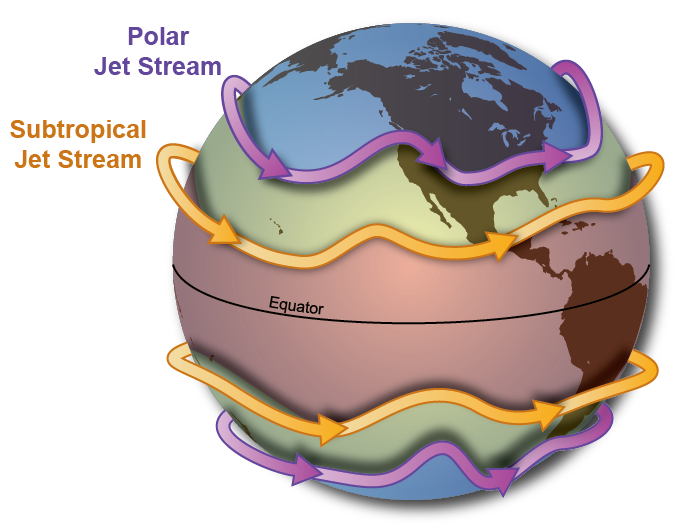


**Source: https://www.noaa.gov/jetstream/global/jet-stream**

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as três células de abaixo: <font>

<font size=4 color='#002883'>1.1. Montar o drive para acesso a nossa pasta de trabalho <font>

In [21]:
# @title #### <font color='#002883'> Montar o drive para a importação da livraria utilities_new_version <font>
%%capture

from google.colab import drive
drive.mount('/content/drive')

<font size=4 color='#002883'>1.2. Adicionar o caminho do sistema para a importação do utilities_new_version.py <font>

In [22]:
# @title #### <font color='#002883'> Adicionar o caminho do Drive ao caminho do sistema para importação de módulos <font>
%%capture

import sys
sys.path.append('/content/drive/MyDrive/')

<font size=4 color='#002883'>1.3. Instaçaão de livrarias <font>

In [23]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture

!pip install imgaug
!pip install siphon

# Instalando a Biblioteca Pygrib
!pip install pygrib
#print('\n')

# Instalando a Biblioteca Cartopy
!pip install cartopy
!pip install shapely --no-binary shapely --force
#print('\n')

# Instalando a Biblioteca MetPy
!pip install "numpy<2.0" metpy --upgrade
#!pip install MetPy
#print('\n')

# Instalando a Biblioteca Boto3
!pip install boto3
#print('\n')

# Instalando a Biblioteca NetCDF4
!pip install netcdf4
#print('\n')

# Instalando a biblioteca para trabalhar arquivos .grib com a livraria xarray
!pip install -q cfgrib eccodes

# Instalando / atualizando a Biblioteca GDAL
!apt-add-repository -y ppa:ubuntugis/ubuntugis-unstable
!add-apt-repository -y ppa:ubuntugis/ppa
!apt-get install gdal-bin
!pip install 'gdal==3.0.4'
#print('\n')

# Install ImageMagick
!sudo apt install imagemagick
#print('\n')

<font size=4 color='#002883'>1.4. Reiniciar a sessão de trabalho. Necessário para a importação do módulo de Metpy <font>

In [ ]:
# @title #### <font color='#002883'> Reiniciar sessão devido ao modulo do Metpy <font>
%%capture

import os
os.kill(os.getpid(), 9)

<font size=4 color='#002883'> **2. Fazer downloand de arquivos complementários (e.g., shapefile de estados e provincias do Brasil e outros paises). Além disso, fazer o download do arquivo utilities.py para o uso no processamento de imagens de satélite da série GOES. Download do arquivo CPT para o realce do canal infravermelho e vapor d'água.** <font>

In [1]:
# @title #### <font color='#002883'> Baixar arquivos complementários <font>
%%capture

# Baixando o shapefile dos estados brasileiros
!wget -c https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados brasileiros
!unzip -o br_unidades_da_federacao.zip
#print('\n')

# Baixando o shapefile dos estados / províncias mundiais
!wget -c https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/10m/cultural/ne_10m_admin_1_states_provinces.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados / províncias mundiais
!unzip -o ne_10m_admin_1_states_provinces.zip
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais IR)
!wget -c https://www.dropbox.com/s/fdgnaqt91cy3x97/IR4AVHRR6.cpt
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais WV)
!wget -c https://www.dropbox.com/s/4l9fys6pv5c68xk/SVGAWVX_TEMP.cpt
#print('\n')

<font size=4 color='#002883'> **3. Importar livrarias.** <font>

In [2]:
# @title #### <font color='#002883'> Importar livrarias para o processamento dos dados <font>
%%capture

from datetime import datetime
import os
import requests
import time as t

# Livrarias para leitura, processamento e plot de dados NetCDF
from netCDF4 import Dataset
from osgeo import gdal
import matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import os
import numpy as np
from matplotlib import cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from datetime import timedelta, date, datetime
import pygrib
import xarray as xr
gdal.PushErrorHandler('CPLQuietErrorHandler')

# Livrarias para o cálculo de campos meteorológicos
from metpy.units import units
import metpy.calc as mpcalc
import numpy.ma as ma

# Carregar a nova versão do utilities_new_version.py
import sys
folder_path = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-II-2026'
if folder_path not in sys.path:
    sys.path.append(folder_path)
from utilities_new_version import download_CMI
from utilities_new_version import reproject
from utilities_new_version import loadCPT

<font size=4 color='#002883'> **4. Função para o download dos dados do modelo Global forecasting System (GFS).** <font>

In [3]:
# @title #### <font color='#002883'> Construir função para o download dos arquivos do GFS <font>
%%capture

# Link (select "grib filter" and check "Show the URL only for web programming" to verify the URL's):
# https://nomads.ncep.noaa.gov/

def download_gfs(date, iii):

    # Create the URL's based on the resolution
    if (resolution == '25'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '50'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2full.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '1'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_'+resolution+'p00.pl?file=gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)
        res = 'prgb2.'+resolution+'p00.f'

    # Print the file name
    print("File name: ", file_name)
    # Sends a GET request to the specified url
    myfile = requests.get(url)

    # Download the file
    open(dir + '//' + file_name, 'wb').write(myfile.content)

<font size=4 color='#002883'> **5. Download dos dados do modelo Global forecasting System (GFS). É necessário editar a data Year = YYYY, month = mm, day = dd e hour = hh. Os dados do GFS só estão disponíveis até 5 dias atrás da data atual.** <font>

In [4]:
# @title #### <font color='#002883'> Download dos dados do GFS <font>
#%%capture

# Configurar a data de acesso aos dados do GFS
year = 2026
month = 8
day = 17
hour = 00

# Extensão desejada - COLOCAR AQUI ENTRE ASPAS POIS É UMA STRING
# longitude de -180 a 180
min_lon = '-122.50'
max_lon = '12.50'
min_lat = '-80.0'
max_lat = '25.0'

print('---------------------------------------')
print('GFS Download (NOMADS) - Script started.')
print('---------------------------------------')

# Start the time counter
start_time = t.time()

# Data desejada (Únicamente os últimos 10 dias!): Formato - 'YYYY, MM, DD, HH'
dt = datetime(year, month, day, hour)
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite

#-----------------------------------------------------------------------------------------------------------

# Download diretório
dir = "Samples"; os.makedirs(dir, exist_ok=True)

# Data desajada (Únicamente os últimos 10 dias!): Formato - 'YYYYMMDD'
date = (f'{dt:%Y%m%d}')

# Resolução espacial desejada: '25' or '50' or '1'
resolution = '25' #'1'

# Hora de execução: '00' or '06' or '12' or '18'
#hour_run = '00'
hour_run=(f'{dt:%H}')

# Horas de previsão
hour_ini = 0  # Init time
hour_end = 0 # End time
hour_int = 3  # Interval

if (resolution == '25'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '50'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '1'):
  res = 'pgrb2.'+resolution+'p00.f'

#-----------------------------------------------------------------------------------------------------------

# Download loop
for hour in range(hour_ini, hour_end + 1, hour_int):
    print('\n---------------------')
    print('Downloading GFS File:')
    print('---------------------')
    print('Resolution: ' + resolution)
    print('Date: ' + date)
    print('Run: ' + hour_run)
    print('Forecast Hour: f' + str(hour).zfill(3))
    # Call the download function
    download_gfs(date,hour)

# End the time counter
print('\nTotal Processing Time:', round((t.time() - start_time),2), 'seconds.')

---------------------------------------
GFS Download (NOMADS) - Script started.
---------------------------------------

---------------------
---------------------
Resolution: 25
Date: 20260817
Run: 00
Forecast Hour: f000
File name:  gfs.t00z.pgrb2.0p25.f000

Total Processing Time: 19.97 seconds.


<font size=4 color='#002883'> **6. Download dos dados de satélite do GOES-19.** <font>

In [5]:
# @title #### <font color='#002883'> Download de GOES-19 <font>
#%%capture

# Seleção da extensão [min. lon, min. lat, max. lon, max. lat]
# Lembrar que longitude está definida entre -180 e 180
extent = [float(min_lon), float(min_lat), float(max_lon), float(max_lat)]

# Input e output directorios
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

#-----------------------------------------------------------------------------------------------------------
date = (f'{dt:%Y%m%d}')
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite
hour_run=(f'{dt:%H}')

# Download the ABI file channel 13 - Clean IR
file_ir = download_CMI(yyyymmddhhmn, 13, input)

# Variable
var = 'CMI'
# Abrir o dado
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Ler os metadados
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Carregar os dados
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Aplicar a escala, offset e converter de Kelvin para Graus Celcius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reprojeção do arquivo
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Ler a imagem do GOES-19 reprojetada
file = Dataset(filename_ret)

# Acessar aos valores dos pixel
data = file.variables['Band1'][:]

File /content/Samples/OR_ABI-L2-CMIPF-M6C13_G19_s20262290000215_e20262290009535_c20262290009583.nc exists


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


<font size=4 color='#002883'> **7. Definir os campos meteorológicos por níveis do GFS.** <font>

In [6]:
# @title #### <font color='#002883'> Definir as variáveis do GFS por níveis <font>
%%capture

# Ler o dado grib do GFS
grib = pygrib.open(f'Samples/gfs.t{hour_run}z.{res}000')

# Selecionar a variável
mslp = grib.select(name='Pressure reduced to MSL')[0]

# Acessar informação do arquivo
init  = str(mslp.analDate)      # Init date / time
run   = str(mslp.hour).zfill(2) # Run
ftime = str(mslp.forecastTime)  # Forecast hour
valid = str(mslp.validDate)     # Valid date / time
print('Init: ' + init + ' UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Ler a data da região específica
# Longitude tem que estar entre 0 e 360 graus
mslp, lats, lons = mslp.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])

# Converter para hPa
mslp = mslp / 100
# Selecionar a variável
prtwt = grib.select(name='Precipitable water')[0]
prtwt = prtwt.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_1000 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 1000)[0]
# Read the data for a specific region
hght_1000 = hght_1000.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_850 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Read the data for a specific region
hght_850 = hght_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_700 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Read the data for a specific region
hght_700 = hght_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_500 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Read the data for a specific region
hght_500 = hght_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_250 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Read the data for a specific region
hght_250 = hght_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Calculate and smooth 1000-500 hPa thickness
thickness_1000_500 = hght_500 - hght_1000
# Calculate and smooth 1000-850 hPa thickness
thickness_1000_850 = hght_850 - hght_1000

# Selecionar a variável
u_925 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
u_925, lats, lons = u_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_925 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
v_925 = v_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
u_250 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
u_250, lats, lons = u_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_250 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
v_250 = v_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
w_850 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
w_850 = w_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
w_500 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Ler a data para a região específica
w_500 = w_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
temp_850 = grib.select(name='Temperature', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
temp_850 = temp_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
relhum_800 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 800)[0]
# Ler a data para a região específica
relhum_800 = relhum_800.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_850 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
relhum_850 = relhum_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_700 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Ler a data para a região específica
relhum_700 = relhum_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Busca a variável de taxa de precipitação na superfície
precip_rate = grib.select(name='Precipitation rate', typeOfLevel='surface')[0]
#-----------------------------------------------------------------------------------------------------------

# calculando umidade relativa média entre 800 e 700 hPa
relhum = (relhum_800 + relhum_850 + relhum_700)/3

# Calculando divergencia em 925 hPa
nivel=925
pressure = units('Pa')*nivel*100
u_925 = units('m/s')*u_925
v_925 = units('m/s')*v_925
# Calculando com metpy
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
# Compute the divergence
div_925 = mpcalc.divergence(u_925, v_925, dx=dx, dy=dy)
# quero somente convergencia
mask_conv = ma.masked_greater_equal(div_925, 0).mask
div_925[mask_conv] = np.nan

# Calculando divergencia em 250 hPa
nivel=250
pressure = units('Pa')*nivel*100
u_250 = units('m/s')*u_250
v_250 = units('m/s')*v_250
# Calculando com metpy
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
# Compute the divergence
div_250 = mpcalc.divergence(u_250, v_250, dx=dx, dy=dy)
# quero somente divergencia
mask_div = ma.masked_less_equal(div_250, 0).mask
div_250[mask_div] = np.nan

# Quero somente os valores negativos de omega
mask_omega = ma.masked_greater_equal(w_850, 0).mask
w_850[mask_omega] = np.nan

mask_omega = ma.masked_greater_equal(w_500, 0).mask
w_500[mask_omega] = np.nan

# Quero somente valores maiores q 40
mask_prtwt = ma.masked_less(prtwt, 40).mask
prtwt[mask_prtwt] = np.nan

<font size=4 color='red'> **Observação: Para listar as variáveis disponíveis pelo modelo GFS, rodar a seguinte célular.** <font>

In [ ]:
# @title #### <font color='red'> Listar variáveis do modelo GFS <font>
%%capture

for grb in grib:
    print(grb)  # Imprime diretamente: número, nome, unidades, tipo de nível e valor do nível

grib.close()

<font size=4 color='#002883'> **8. Converter a Analysis do modelo GFS do formato .grib2 para o formato .nc (NetCDF). Com os dados no formato NetCDF é possível fazer os corter verticais para identificação do Jato Subtropical (JST) e do Jato Polar (JP)** <font>


<font size=4 color='red'> **Observação: Só as variáveis com níveis de pressão ("typeOfLevel": "isobaricInhPa") que serão transformadas do formato .grib2 para o formato .nc** <font>

In [7]:

# @title #### <font color='#002883'> Transformar do formato .grib2 para .nc (Só as variáveis com níveis de pressão que serão transformadas) <font>
#%%capture

import logging

# Silencia os logs do cfgrib
logging.getLogger("cfgrib").setLevel(logging.CRITICAL)

ds = xr.open_dataset(
    f'Samples/gfs.t{hour_run}z.{res}000',
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "isobaricInhPa"
        },
        "indexpath": ""
    }
)

ds

<xarray.Dataset> Size: 301MB
Dimensions:        (isobaricInhPa: 33, latitude: 421, longitude: 541)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 264B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude       (latitude) float64 3kB -80.0 -79.75 -79.5 ... 24.5 24.75 25.0
  * longitude      (longitude) float64 4kB -122.5 -122.2 -122.0 ... 12.25 12.5
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    gh             (isobaricInhPa, latitude, longitude) float32 30MB ...
    t              (isobaricInhPa, latitude, longitude) float32 30MB ...
    r              (isobaricInhPa, latitude, longitude) float32 30MB ...
    q              (isobaricInhPa, latitude, longitude) float32 30MB ...
    w              (isobaricInhPa, latitude, longitude) float32 30MB ...
    wz             (isobaricInhPa, latitude, longitude) float32 30MB ...
    u              (isobaricInhPa, latitude, longitude) float32 30MB ...
    v              (isobaricInhPa, latitude, longitude) float32 30MB ...
    absv           (isobaricInhPa, latitude, longitude) float32 30MB ...
    o3mr           (isobaricInhPa, latitude, longitude) float32 30MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-08-17T20:57 GRIB to CDM+CF via cfgrib-0.9.1...

<font size=4 color='#002883'> **9. Calculando a velocidade do vento considerando só as componentes zonal (u) e meridional (v). Além disso, calculando a Temperatura Potencialo fazendo uso da livraria Metpy** <font>

In [8]:
# @title #### <font color='#002883'> Cálculo da magnitude da velocidade do vento e da Temperatura Potencial <font>
%%capture

# MAGNITUDE DO VENTO
ds['wind_speed'] = mpcalc.wind_speed(ds['u'], ds['v'])  #np.sqrt(ds['u']**2 + ds['v']**2)

# Use MetPy to calculate the wind speed for colorfill plot, change units to knots from m/s
speed_jet = mpcalc.wind_speed(u_250, v_250)

#Quero somente os valores maiores que 30 m/s
mask_jet = ma.masked_less_equal(speed_jet, 30).mask
speed_jet[mask_jet] = np.nan

# TEMPERATURA POTENCIAL
ds['theta'] = mpcalc.potential_temperature(ds['isobaricInhPa'], ds['t'])
ds

<font size=4 color='red'> **Identificação dos Jato Subtropical (JST), Jato Polar Norte (JPN) e Jato Polar Sul (JPS)** <font>


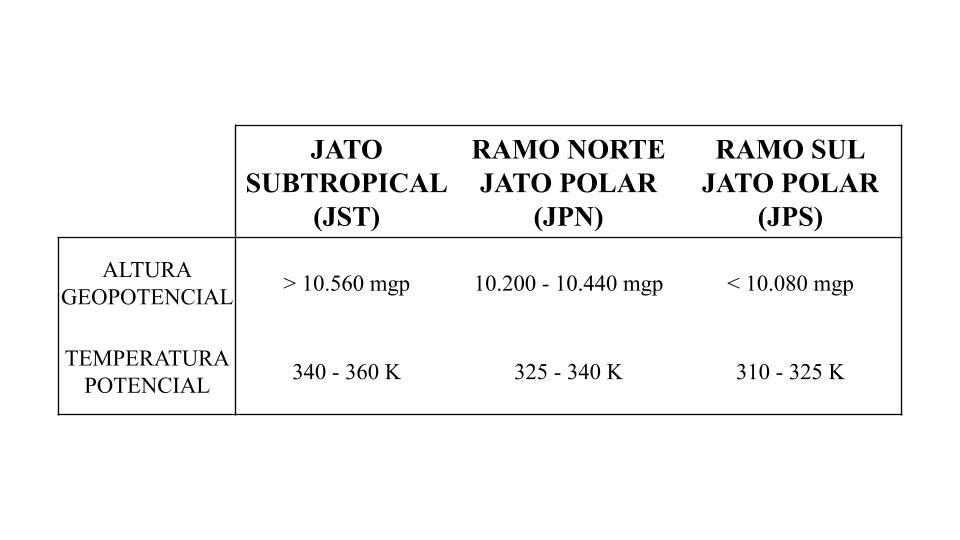

<font size=4 color='#002883'> **10. Velocidade do vento (Jet, m/s) + Altura Geopotencial (Z, dam) | Nível 250 hPa** <font>

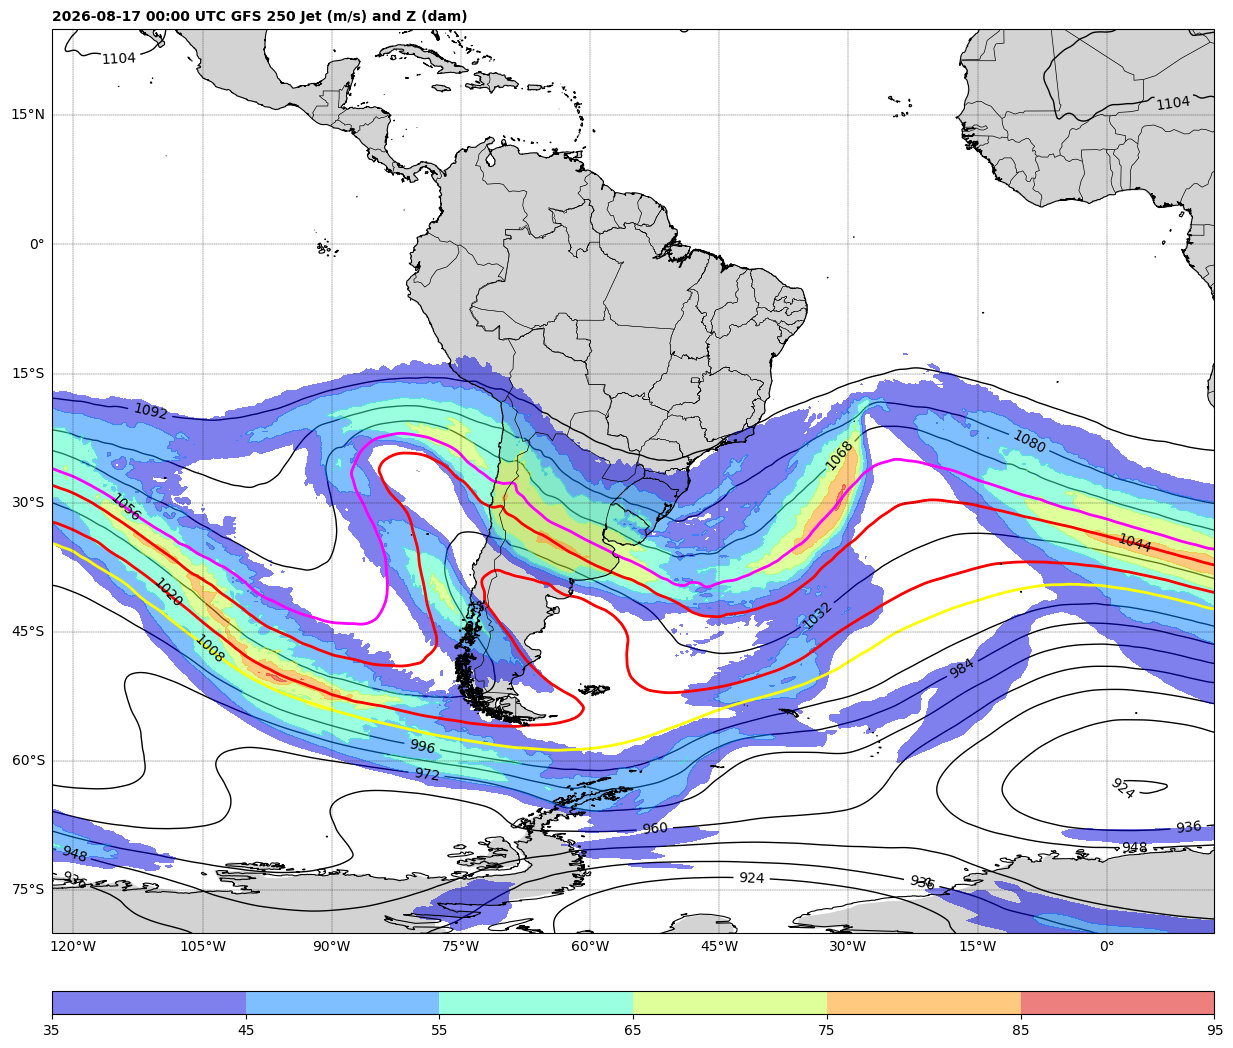

In [13]:
# @title #### <font color='#002883'> Jato Subtropical, Jato Polar Ramo Norte e Jato Polar Ramo Sul <font>
#%%capture

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# 250-hPa jet
clevjet = np.arange(35,96,10)

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Plot Geopotential Heights
clevs_hght_250 = np.arange(0, 2000, 12)
# Suavizado da altura gepotencial
hght_250 = mpcalc.smooth_gaussian(hght_250, 4)

cs = ax.contour(lons, lats, hght_250/10, clevs_hght_250, linewidths=1.0, colors='black', transform=ccrs.PlateCarree())
plt.clabel(cs, fmt='%d')

# ================================================== IDENTIFICAÇÃO DOS JATOS ===================================================================
# 250-hPa jet
clevjet = np.arange(35,96,10)
jet250 = ax.contourf(lons, lats, speed_jet, clevjet, cmap='jet', alpha=0.5, zorder=2, transform=ccrs.PlateCarree())
plt.colorbar(jet250, orientation='horizontal', pad=0.05, aspect=50, extendrect=True)

# Plot Z - Jato Subtropical
clevzjet_subtropical = np.arange(10560., 10561., 1)
cs = ax.contour(lons, lats, hght_250, clevzjet_subtropical, colors='magenta', linewidths=2.0, linestyles='-',transform=ccrs.PlateCarree())

# Plot Z - Ramo norte do Jato Polar
clevzjet_polar_norte = np.arange(10200., 10500., 240)
cs = ax.contour(lons, lats, hght_250, clevzjet_polar_norte, colors='red', linewidths=2.0,linestyles='-',transform=ccrs.PlateCarree())

# Plot Z - Ramo Sul do Jato Polar
clevzjet_polar_sul = np.arange(10080., 10081., 1)
cs = ax.contour(lons, lats, hght_250, clevzjet_polar_sul, colors='yellow', linewidths=2.0,linestyles='-',transform=ccrs.PlateCarree())

# =============================================================================================================================================

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', zorder=3, linewidth=0.3)

# Adicionar coastlines, borders and gridlines
import cartopy.feature as cfeature
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5, zorder=3)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='black', alpha=1.0,
                  linestyle='--', linewidth=0.25,
                  xlocs=np.arange(-180, 180, 15),
                  ylocs=np.arange(-90, 90, 15),
                  draw_labels=True, zorder=4)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS 250 Jet (m/s) and Z (dam)', fontweight='bold', fontsize=10, loc='left')
#plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')
#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/250_Z_Jatos.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

<font size=4 color='#002883'> **11. Corte vertical com Longitude constante para identificação do Jato Subtropical + Jato Polar Ramo Norte + Jato Polar Ramo Sul** <font>

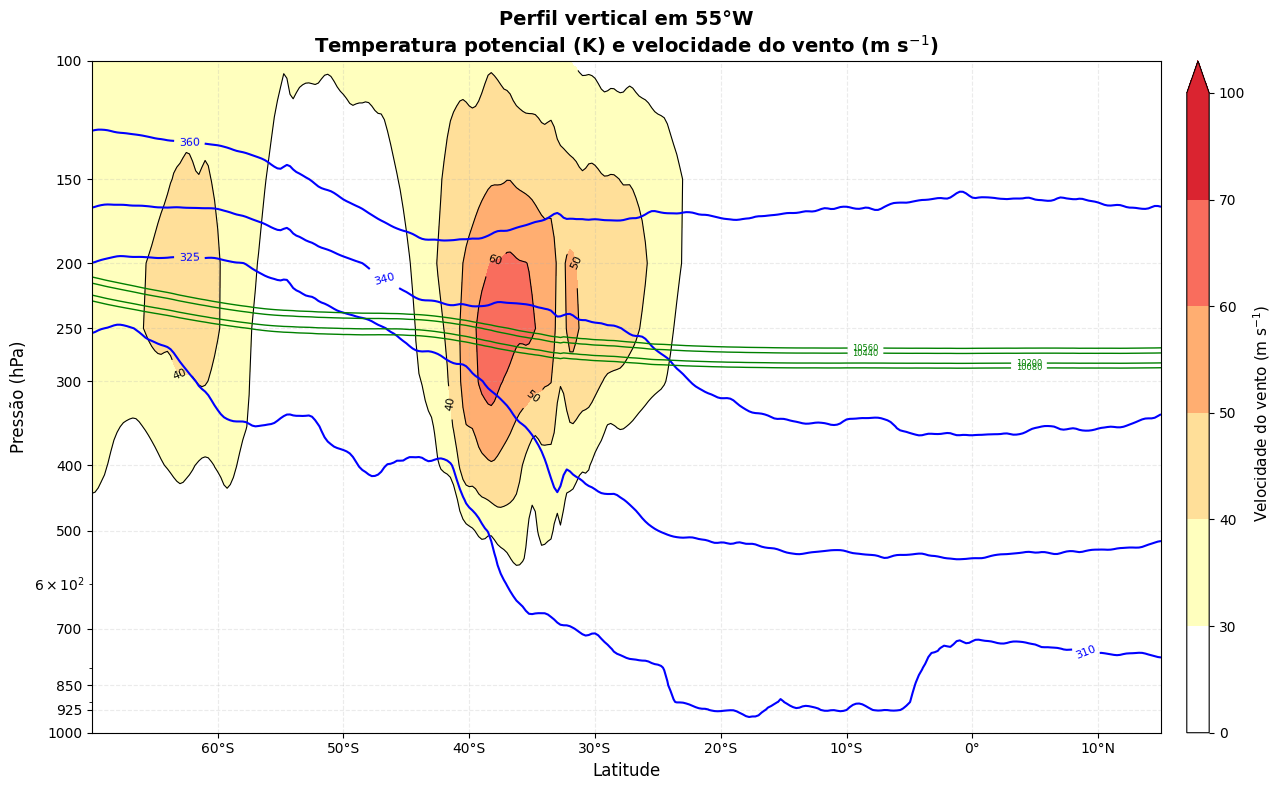

In [10]:
# @title #### <font color='#002883'> Corte vertical - Longitude constante: Jato Subtropical, Jato Polar Ramo Norte e Jato Polar Ramo Sul <font>
#%%capture

# ============================================================
# 1. REMOVER PINT SOMENTE PARA O PLOT
# ============================================================

# Se o dataset foi quantificado com MetPy/Pint,
# converte novamente para valores numéricos mantendo
# as unidades como atributos.

try:
    ds_plot = ds.metpy.dequantify()
except Exception:
    ds_plot = ds.copy()


# ============================================================
# 2. CONFIGURAÇÕES DO CORTE
# ============================================================

lon_corte = -55.0

lat_min = -70
lat_max = 15

p_min = 50
p_max = 1000

# ============================================================
# 3. SELECIONAR LONGITUDE
# ============================================================

section = ds_plot.sel(longitude=lon_corte, method="nearest")

# ============================================================
# 4. SELECIONAR LATITUDE
# ============================================================

# Detecta automaticamente a direção da latitude
if section.latitude.values[0] < section.latitude.values[-1]:
    # crescente: -90 -> 90
    section = section.sel(latitude=slice(lat_min, lat_max))
else:
    # decrescente: 90 -> -90
    section = section.sel(latitude=slice(lat_max, lat_min))

# ============================================================
# 5. SELECIONAR PRESSÃO
# ============================================================

# Detecta automaticamente a direção dos níveis
if (section.isobaricInhPa.values[0] < section.isobaricInhPa.values[-1]):
    # crescente
    section = section.sel(isobaricInhPa=slice(p_min, p_max))
else:
    # decrescente
    section = section.sel(isobaricInhPa=slice(p_max, p_min))

# ============================================================
# 6. VARIÁVEIS
# ============================================================

T = section["t"]
u = section["u"]
v = section["v"]
wind_speed = section["wind_speed"]
theta = section["theta"]
z = section["gh"]

# Suavizar variáveis
theta = mpcalc.smooth_gaussian(theta, 6)
wind_speed = mpcalc.smooth_gaussian(wind_speed, 6)

# ============================================================
# 7. GARANTIR ORDEM PRESSÃO x LATITUDE
# ============================================================

wind_speed = wind_speed.transpose("isobaricInhPa", "latitude")
theta = theta.transpose("isobaricInhPa", "latitude")
z = z.transpose("isobaricInhPa", "latitude")

# ============================================================
# 8. COORDENADAS
# ============================================================

pressure = wind_speed["isobaricInhPa"].values
latitude = wind_speed["latitude"].values

# ============================================================
# 10. PALETA DO JATO
# ============================================================

colors_jet = [
    "#FFFFFF",
    "#FFFFBE",
    "#FFDF99",
    "#FFAE71",
    "#F96D5D",
    "#DA2430",
]

cmap_jet = ListedColormap(colors_jet)
levels_jet = [0, 30, 40, 50, 60, 70, 100]
norm = BoundaryNorm(levels_jet, cmap_jet.N)


# ============================================================
# 11. FIGURA
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# ============================================================
# JATO - SOMBREADO
# ============================================================

cf = ax.contourf(
    latitude,
    pressure,
    wind_speed.values,
    levels=levels_jet,
    cmap=cmap_jet,
    norm=norm,
    extend="max"
)


# ============================================================
# JATO - CONTORNOS
# ============================================================

cs_wind = ax.contour(
    latitude,
    pressure,
    wind_speed.values,
    levels=np.arange(30, 81, 10),
    colors="black",
    linewidths=0.8
)

ax.clabel(cs_wind, fmt="%d", fontsize=8)

# ============================================================
# TEMPERATURA POTENCIAL
# ============================================================

# Jato Subtropical
theta_levels_jst = np.arange(360, 361, 20)
cs_theta_jst = ax.contour(
    latitude,
    pressure,
    theta.values,
    levels=theta_levels_jst,
    colors="blue",
    linewidths=1.5
)
ax.clabel(cs_theta_jst, fmt="%d", fontsize=8)

# Jato Polar
theta_levels_jp = np.arange(310, 341, 15)
cs_theta_jp = ax.contour(
    latitude,
    pressure,
    theta.values,
    levels=theta_levels_jp,
    colors="blue",
    linewidths=1.5
)
ax.clabel(cs_theta_jp, fmt="%d", fontsize=8)

# ============================================================
# ALTURA GEOPOTENCIAL
# ============================================================

# Jato Subtropical
z_levels_jst = np.arange(10560, 10561, 1)
cs_z_jst = ax.contour(
    latitude,
    pressure,
    z.values,
    levels=z_levels_jst,
    colors="green",
    linewidths=1.0
)
ax.clabel(cs_z_jst, fmt="%d", fontsize=6)

# Jato Polar Norte
z_levels_jpn = np.arange(10200, 10441, 240)
cs_z_jpn = ax.contour(
    latitude,
    pressure,
    z.values,
    levels=z_levels_jpn,
    colors="green",
    linewidths=1.0
)
ax.clabel(cs_z_jpn, fmt="%d", fontsize=6)

# Jato Polar Sul
z_levels_jps = np.arange(10080, 10081, 1)
cs_z_jps = ax.contour(
    latitude,
    pressure,
    z.values,
    levels=z_levels_jps,
    colors="green",
    linewidths=1.0
)
ax.clabel(cs_z_jps, fmt="%d", fontsize=6)

# ============================================================
# 12. EIXO VERTICAL
# ============================================================

ax.set_yscale("log")
ax.set_ylim(1000, 100)
pressure_ticks = [1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]
ax.set_yticks(pressure_ticks)
ax.set_yticklabels([str(p) for p in pressure_ticks])


# ============================================================
# 13. EIXO DE LATITUDE
# ============================================================

lat_ticks = np.arange(-60, 16, 10)
lat_labels = []

for lat in lat_ticks:
    if lat < 0:
        lat_labels.append(f"{abs(lat):.0f}°S")
    elif lat > 0:
        lat_labels.append(f"{lat:.0f}°N")
    else:
        lat_labels.append("0°")


ax.set_xticks(lat_ticks)
ax.set_xticklabels(lat_labels)

# ============================================================
# 15. COLORBAR
# ============================================================

cbar = plt.colorbar(cf, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Velocidade do vento (m s$^{-1}$)", fontsize=11)

# ============================================================
# 16. LABELS
# ============================================================
ax.set_xlabel("Latitude", fontsize=12)
ax.set_ylabel("Pressão (hPa)", fontsize=12)
ax.set_title(
    f"Perfil vertical em {abs(lon_corte):.0f}°W\n"
    "Temperatura potencial (K) e velocidade do vento (m s$^{-1}$)",
    fontsize=14,
    fontweight="bold"
)


ax.grid(linestyle="--", alpha=0.25)


plt.tight_layout()

plt.show()

<font size=4 color='#002883'> **12. Corte vertical com Latitude constante para identificação do Jato Subtropical + Jato Polar Ramo Norte + Jato Polar Ramo Sul** <font>

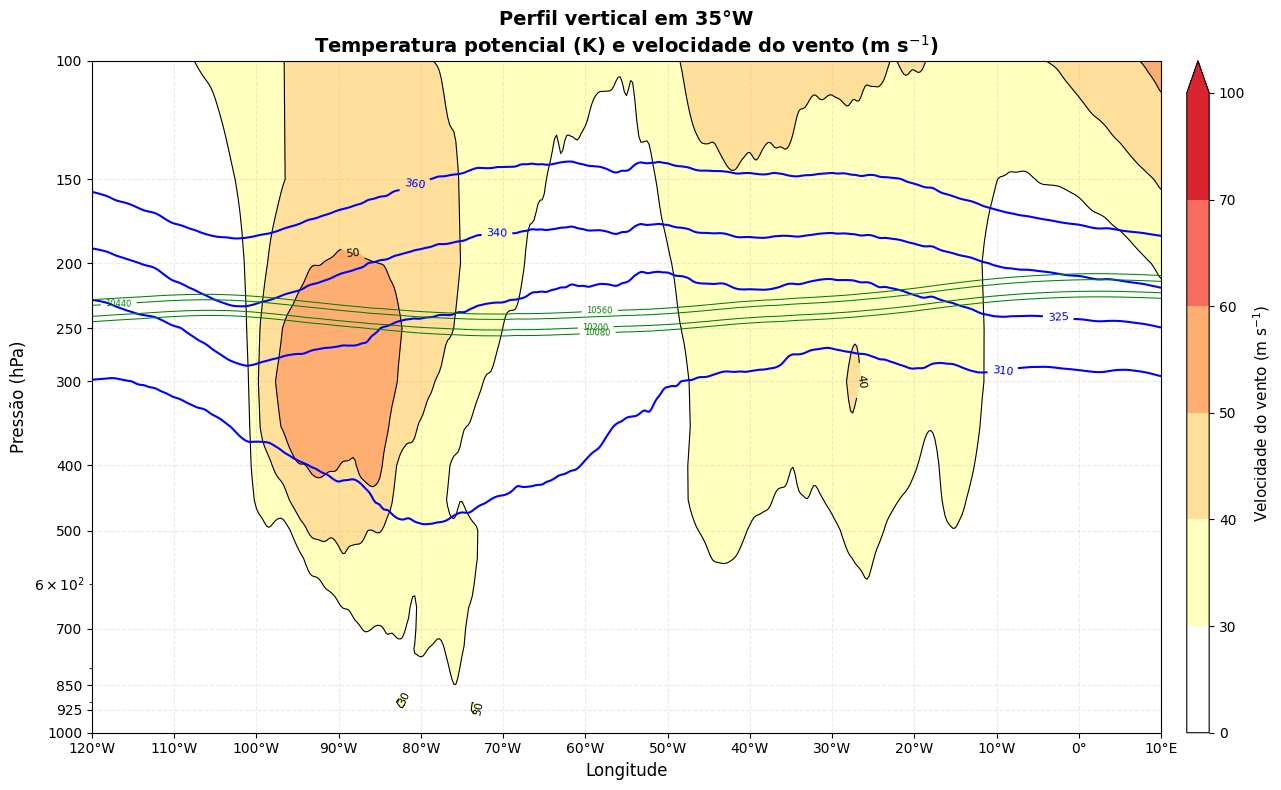

In [11]:
# @title #### <font color='#002883'> Corte vertical - Latitude constante: Jato Subtropical, Jato Polar Ramo Norte e Jato Polar Ramo Sul <font>
#%%capture

# ============================================================
# 1. REMOVER PINT SOMENTE PARA O PLOT
# ============================================================

# Se o dataset foi quantificado com MetPy/Pint,
# converte novamente para valores numéricos mantendo
# as unidades como atributos.

try:
    ds_plot = ds.metpy.dequantify()
except Exception:
    ds_plot = ds.copy()


# ============================================================
# 2. CONFIGURAÇÕES DO CORTE
# ============================================================

lat_corte = -35.0

lon_min = -120
lon_max = 10

p_min = 50
p_max = 1000

# ============================================================
# 3. SELECIONAR LATITUDE
# ============================================================

section = ds_plot.sel(latitude=lon_corte, method="nearest")

# ============================================================
# 4. SELECIONAR LONGITUDE
# ============================================================

# Detecta automaticamente a direção da latitude
if section.longitude.values[0] < section.longitude.values[-1]:
    # crescente: -180 -> 180
    section = section.sel(longitude=slice(lon_min, lon_max))
else:
    # decrescente: 180 -> -180
    section = section.sel(longitude=slice(lon_max, lon_min))

# ============================================================
# 5. SELECIONAR PRESSÃO
# ============================================================

# Detecta automaticamente a direção dos níveis
if (section.isobaricInhPa.values[0] < section.isobaricInhPa.values[-1]):
    # crescente
    section = section.sel(isobaricInhPa=slice(p_min, p_max))
else:
    # decrescente
    section = section.sel(isobaricInhPa=slice(p_max, p_min))

# ============================================================
# 6. VARIÁVEIS
# ============================================================

T = section["t"]
u = section["u"]
v = section["v"]
wind_speed = section["wind_speed"]
theta = section["theta"]
z = section["gh"]

# Suavizar variáveis
theta = mpcalc.smooth_gaussian(theta, 6)
wind_speed = mpcalc.smooth_gaussian(wind_speed, 6)

# ============================================================
# 7. GARANTIR ORDEM PRESSÃO x LATITUDE
# ============================================================

wind_speed = wind_speed.transpose("isobaricInhPa", "longitude")
theta = theta.transpose("isobaricInhPa", "longitude")
z = z.transpose("isobaricInhPa", "longitude")

# ============================================================
# 8. COORDENADAS
# ============================================================

pressure = wind_speed["isobaricInhPa"].values
longitude = wind_speed["longitude"].values

# ============================================================
# 10. PALETA DO JATO
# ============================================================

colors_jet = [
    "#FFFFFF",
    "#FFFFBE",
    "#FFDF99",
    "#FFAE71",
    "#F96D5D",
    "#DA2430",
]

cmap_jet = ListedColormap(colors_jet)
levels_jet = [0, 30, 40, 50, 60, 70, 100]
norm = BoundaryNorm(levels_jet, cmap_jet.N)


# ============================================================
# 11. FIGURA
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# ============================================================
# JATO - SOMBREADO
# ============================================================

cf = ax.contourf(
    longitude,
    pressure,
    wind_speed.values,
    levels=levels_jet,
    cmap=cmap_jet,
    norm=norm,
    extend="max"
)


# ============================================================
# JATO - CONTORNOS
# ============================================================

cs_wind = ax.contour(
    longitude,
    pressure,
    wind_speed.values,
    levels=np.arange(30, 81, 10),
    colors="black",
    linewidths=0.8
)

ax.clabel(cs_wind, fmt="%d", fontsize=8)

# ============================================================
# TEMPERATURA POTENCIAL
# ============================================================

# Jato Subtropical
theta_levels_jst = np.arange(360, 361, 20)
cs_theta_jst = ax.contour(
    longitude,
    pressure,
    theta.values,
    levels=theta_levels_jst,
    colors="blue",
    linewidths=1.5
)
ax.clabel(cs_theta_jst, fmt="%d", fontsize=8)

# Jato Polar
theta_levels_jp = np.arange(310, 341, 15)
cs_theta_jp = ax.contour(
    longitude,
    pressure,
    theta.values,
    levels=theta_levels_jp,
    colors="blue",
    linewidths=1.5
)
ax.clabel(cs_theta_jp, fmt="%d", fontsize=8)

# ============================================================
# ALTURA GEOPOTENCIAL
# ============================================================

# Jato Subtropical
z_levels_jst = np.arange(10560, 10561, 1)
cs_z_jst = ax.contour(
    longitude,
    pressure,
    z.values,
    levels=z_levels_jst,
    colors="green",
    linewidths=0.75
)
ax.clabel(cs_z_jst, fmt="%d", fontsize=6)

# Jato Polar Norte
z_levels_jpn = np.arange(10200, 10441, 240)
cs_z_jpn = ax.contour(
    longitude,
    pressure,
    z.values,
    levels=z_levels_jpn,
    colors="green",
    linewidths=0.75
)
ax.clabel(cs_z_jpn, fmt="%d", fontsize=6)

# Jato Polar Sul
z_levels_jps = np.arange(10080, 10081, 1)
cs_z_jps = ax.contour(
    longitude,
    pressure,
    z.values,
    levels=z_levels_jps,
    colors="green",
    linewidths=0.75
)
ax.clabel(cs_z_jps, fmt="%d", fontsize=6)

# ============================================================
# 12. EIXO VERTICAL
# ============================================================

ax.set_yscale("log")
ax.set_ylim(1000, 100)
pressure_ticks = [1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]
ax.set_yticks(pressure_ticks)
ax.set_yticklabels([str(p) for p in pressure_ticks])


# ============================================================
# 13. EIXO DE LATITUDE
# ============================================================

lon_ticks = np.arange(-120, 11, 10)
lon_labels = []

for lon in lon_ticks:
    if lon < 0:
        lon_labels.append(f"{abs(lon):.0f}°W")
    elif lon > 0:
        lon_labels.append(f"{lon:.0f}°E")
    else:
        lon_labels.append("0°")


ax.set_xticks(lon_ticks)
ax.set_xticklabels(lon_labels)

# ============================================================
# 15. COLORBAR
# ============================================================

cbar = plt.colorbar(cf, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Velocidade do vento (m s$^{-1}$)", fontsize=11)

# ============================================================
# 16. LABELS
# ============================================================
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Pressão (hPa)", fontsize=12)
ax.set_title(
    f"Perfil vertical em {abs(lat_corte):.0f}°W\n"
    "Temperatura potencial (K) e velocidade do vento (m s$^{-1}$)",
    fontsize=14,
    fontweight="bold"
)


ax.grid(linestyle="--", alpha=0.25)


plt.tight_layout()

plt.show()